In [1]:
from pathlib import Path

import torch as tc
import torchvision.transforms.v2 as tvs
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm import tqdm

from models import ScatNet

RNG = tc.Generator().manual_seed(0)

# FIXME: remove transforms from validation and testing subsets
train_transforms = tvs.Compose([
    tvs.Grayscale(),
    tvs.ToTensor(),
    tvs.ToDtype(tc.float32, scale=True),
    # bit of data augmentation
    tvs.RandomHorizontalFlip(),
    tvs.GaussianNoise(sigma=0.05),
    tvs.RandomResizedCrop(100, scale=(0.8, 1)),
    tvs.Normalize(mean=(0.5,), std=(0.5,)), # TODO: compute statistics from dataset instead
])
test_transforms = tvs.Compose([
    tvs.ToImage(),
    tvs.Grayscale(),
    tvs.ToDtype(tc.float32, scale=True),
    tvs.Resize(100),
    tvs.Normalize(mean=(0.5,), std=(0.5,)), # TODO: compute statistics from dataset instead
])

dataset = ImageFolder("data/cats_and_dogs/PetImages", transform=train_transforms)
SHAPE = (1, 100, 100)

import numpy as np
class_labels = np.array(dataset.targets)
class_0_count = np.count_nonzero(class_labels == 0)
class_1_count = np.count_nonzero(class_labels == 1)
print(dataset.classes[0], ":", class_0_count)
print(dataset.classes[1], ":", class_1_count)

Cat : 12499
Dog : 12499


c:\Users\User\Desktop\ADR\Repository\xai-binary-classification\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [2]:
BATCH_SIZE: int = 500
WORKERS: int = 4

devel_dataset, test_dataset = tc.utils.data.random_split(dataset, [0.8, 0.2], generator=RNG)

device = tc.device("cuda")

model = ScatNet(shape=SHAPE).to(device)
# model.compile()
print(model)

ScatNet(
  (features): Scattering2D()
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6129, out_features=640, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=640, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=128, out_features=1, bias=True)
  )
)


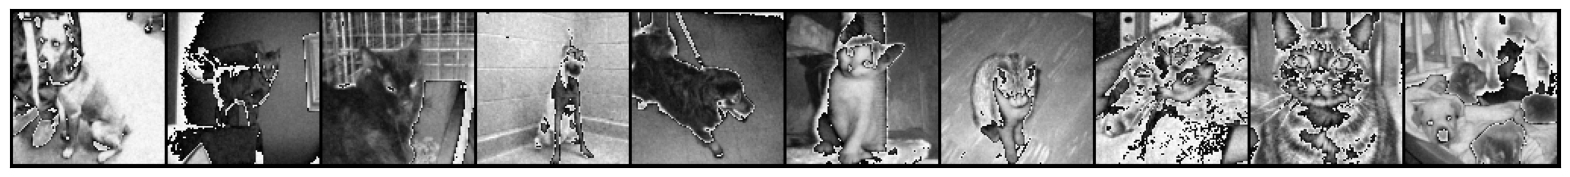

In [3]:
from torchvision.utils import make_grid
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torchvision.transforms.functional as F

examples = tc.stack([devel_dataset[i][0] for i in range(10)])

def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fix, axs = plt.subplots(squeeze=False, figsize=(20, 20))
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

grid = make_grid(examples, nrow=20)
show(grid)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

EPOCHS: int = 50


# apply weight decay only to convolution layers
decaying = []
not_decaying = []
for m in model.modules():
    if isinstance(m, (tc.nn.Linear, tc.nn.Conv2d)):
        decaying.append(m.weight)
        not_decaying.append(m.bias)
    elif hasattr(m, 'weight'):
        not_decaying.append(m.weight)
    elif hasattr(m, 'bias'):
        not_decaying.append(m.bias)

grouped_parameters = [
    {"params": decaying, "weight_decay": 0.01},
    {"params": not_decaying, "weight_decay": 0.0}
]

pos_weight = tc.tensor(class_0_count / class_1_count)
print("Class imbalance:", pos_weight)
criterion = tc.nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device)
optimizer = tc.optim.AdamW(grouped_parameters, lr=0.01)
scheduler = tc.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

acc_train = []; f1_train = []; loss_train = []
acc_valid = []; f1_valid = []; loss_valid = []

train_subset, valid_subset = tc.utils.data.random_split(devel_dataset, [0.8, 0.2], generator=RNG)
train_loader = DataLoader(
    train_subset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=WORKERS,
    pin_memory=True,
)
valid_loader = DataLoader(
    valid_subset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=WORKERS,
    pin_memory=True,
)

# for epoch in tqdm(range(EPOCHS), "Training"):
for epoch in range(EPOCHS):
    print(f"Epoch: {epoch}")

    # training phase
    running_loss = []
    running_acc = []
    running_f1 = []
    model.train()
    for images, labels in tqdm(train_loader, "Train on batches"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(dim=-1)
        loss = criterion(outputs, labels.float())
        loss.backward()
        optimizer.step()

        # Compute accuracy, and F1-score
        # predicted = tc.argmax(outputs, dim=-1)
        predicted = tc.sigmoid(outputs).round().detach()
        running_loss.append(loss.item())
        running_acc.append(accuracy_score(labels.cpu(), predicted.cpu()))
        running_f1.append(f1_score(labels.cpu(), predicted.cpu(), average="weighted"))
        # print("Batch accuracy score", accuracy_score(labels.cpu(), predicted.cpu()))

    loss_train.append(np.mean(running_loss))
    acc_train.append(np.mean(running_acc))
    f1_train.append(np.mean(running_f1))

    print(f"Train - Loss: {loss_train[epoch]:.4f}, Acc: {acc_train[epoch]:.4f}, F1: {f1_train[epoch]:.4f}")

    # validation phase
    model.eval()
    running_loss = []
    running_acc = []
    running_f1 = []
    with tc.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images).squeeze(dim=-1)
            loss = criterion(outputs, labels.float())

            # predicted = tc.argmax(outputs, dim=-1)
            predicted = tc.sigmoid(outputs).round().detach()
            running_loss.append(loss.item())
            running_acc.append(accuracy_score(labels.cpu(), predicted.cpu()))
            running_f1.append(
                f1_score(labels.cpu(), predicted.cpu(), average="weighted")
            )

        loss_valid.append(np.mean(running_loss))
        acc_valid.append(np.mean(running_acc))
        f1_valid.append(np.mean(running_f1))

        print(f"Valid - Loss: {loss_valid[epoch]:.4f}, Acc: {acc_valid[epoch]:.4f}, F1: {f1_valid[epoch]:.4f}")

    # bookkeping
    scheduler.step()

Class imbalance: tensor(1., dtype=torch.float64)
Epoch: 0


Train on batches: 100%|██████████| 32/32 [00:27<00:00,  1.15it/s]


Train - Loss: 0.7076, Acc: 0.5387, F1: 0.4519
Valid - Loss: 0.6430, Acc: 0.6249, F1: 0.6067
Epoch: 1


Train on batches: 100%|██████████| 32/32 [00:27<00:00,  1.17it/s]


Train - Loss: 0.6024, Acc: 0.6789, F1: 0.6734
Valid - Loss: 0.5755, Acc: 0.7002, F1: 0.6935
Epoch: 2


Train on batches: 100%|██████████| 32/32 [00:27<00:00,  1.17it/s]


Train - Loss: 0.5520, Acc: 0.7219, F1: 0.7195
Valid - Loss: 0.5248, Acc: 0.7409, F1: 0.7407
Epoch: 3


Train on batches: 100%|██████████| 32/32 [00:19<00:00,  1.68it/s]


Train - Loss: 0.5261, Acc: 0.7429, F1: 0.7413
Valid - Loss: 0.5017, Acc: 0.7624, F1: 0.7624
Epoch: 4


Train on batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
# plot metrics traces
import seaborn as sns

fig, axes = plt.subplots(nrows=3)

sns.lineplot(loss_train, label="train loss", ax=axes[0])
sns.lineplot(loss_valid, label="valid loss", ax=axes[0])
axes[0].set_xlabel("epoch")
axes[0].set_xlabel("loss")
sns.despine(ax=axes[0])
axes[0].grid()

sns.lineplot(acc_train, label="train accuracy", ax=axes[1])
sns.lineplot(acc_valid, label="valid accuracy", ax=axes[1])
axes[1].set_xlabel("epoch")
axes[1].set_xlabel("accuracy")
sns.despine(ax=axes[1])
axes[1].grid()

sns.lineplot(f1_train, label="train f1-score", ax=axes[2])
sns.lineplot(f1_valid, label="valid f1-score", ax=axes[2])
axes[2].set_xlabel("epoch")
axes[2].set_xlabel("f1-score")
sns.despine(ax=axes[2])
axes[2].grid()

plt.tight_layout()
plt.show()

In [ ]:
# test the model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=WORKERS,
    pin_memory=True,
)

def test_model(model: tc.nn.Module, loader: DataLoader):
    model.eval()
    test_pred_labels = []
    test_true_labels = []
    with tc.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(dim=-1)
            # predicted = tc.argmax(outputs, dim=-1)
            predicted = tc.sigmoid(outputs).round().detach()
            test_pred_labels.extend(predicted.cpu().numpy())
            test_true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(test_true_labels, test_pred_labels)
    f1 = f1_score(test_true_labels, test_pred_labels, average='weighted')
    print(f'Test Accuracy: {accuracy:.4f}, Test F1-score: {f1:.4f}')

    cm = confusion_matrix(test_true_labels, test_pred_labels)
    cmd = ConfusionMatrixDisplay(cm, display_labels=dataset.classes)
    cmd.plot(cmap=plt.cm.Blues)

test_model(model, test_loader)

In [ ]:
# visualize filters
# import matplotlib.pyplot as plt
# import torchvision

# for i, layer in enumerate([model.conv0.weight, model.conv1.weight]):
#     print(layer.shape)
#     fig, ax = plt.subplots()
#     ax.set_title(f"conv layer {i}")
#     filters = layer.view(-1, *layer.shape[-2:]).unsqueeze(dim=1)
#     image = torchvision.utils.make_grid(filters.cpu(), nrow=100, normalize=True, scale_each=True)
#     # bring channel axis to the last place
#     ax.imshow(image.numpy().transpose((1, 2, 0)))
#     ax.axis("off")
#     fig.tight_layout()

In [ ]:
# export the trained model

export_folder = Path("weights/")
export_folder.mkdir(exist_ok=True)
export_path = Path(export_folder, f"{model.name}_{EPOCHS}.pt")
print("Exporting model weights to", export_path.resolve())
tc.save(model.state_dict(), export_path)